In [ ]:
# Cell 1: SETUP AND IMPORTS
import step1_loading
import step2_preprocessing
import step3_epoching
import step4_pseudotrials
import step5_decoding
import step6_visualization
import step7_comparison
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configuration
BASIC_PATH = 'project/ds006761'

In [ ]:
# Cell 2: HELPER FUNCTIONS FOR NOTEBOOK WORKFLOW
def process_single_subject(subject_id, player_num=1):
    print(f"Processing {subject_id}, Player {player_num}")
    
    # 1. Load data
    raw_p1, raw_p2 = step1_loading.load_and_split_data(subject_id, BASIC_PATH)
    raw_data = raw_p1 if player_num == 1 else raw_p2
    
    if raw_data is None:
        print(f"❌ No data for Player {player_num}")
        return None
    
    # 2. Preprocess - TRY DIFFERENT WAYS
    print(f"   Preprocessing...")
    
    # Method 1: Try new way (4 arguments)
    try:
        raw_clean = step2_preprocessing.run_preprocessing(
            raw_data, 
            subject_id, 
            BASIC_PATH, 
            player_num
        )
        print("   ✅ Used new preprocessing (with bad channel loading)")
        
    except TypeError:
        # Method 2: Try old way (1 argument)
        print("   ⚠️ Falling back to old preprocessing (no bad channels)")
        raw_clean = step2_preprocessing.run_preprocessing(raw_data)
    
    # 3. Epoch
    print("3. Epoching...")
    epochs_tuple, df_clean = step3_epoching.run_epoching(
        raw_clean, subject_id, BASIC_PATH, player_num
    )
    
    # 4. Create pseudo-trials
    print("4. Creating pseudo-trials...")
    epochs_binned = step4_pseudotrials.bin_and_stitch_time_course(epochs_tuple)
    
    # 5. Decode
    print("5. Decoding...")
    labels = df_clean[f'player{player_num}_resp'].values
    
    # Check which decoding function is available
    if hasattr(step5_decoding, 'run_svm_decoding_with_pseudotrials'):
        print("   Using new decoding with pseudo-trials")
        times, scores, std_scores, _ = step5_decoding.run_svm_decoding_with_pseudotrials(
            epochs_binned, labels, n_folds=10, n_average=4, n_repeats=20
        )
    else:
        print("   Using old decoding function")
        times, scores = step5_decoding.run_svm_decoding_original(epochs_binned, custom_labels=labels)
        std_scores = None
    
    # 6. Plot
    print("6. Plotting results...")
    step6_visualization.plot_paper_replication(
        times, scores, f"{subject_id} - Player {player_num}"
    )
    
    return times, scores, epochs_binned, df_clean

def compare_methods(subject_id, player_num=1):
    """
    Compare your SVM method vs. original LDA method
    """
    # Process data once
    raw_p1, raw_p2 = step1_loading.load_and_split_data(subject_id, BASIC_PATH)
    raw_data = raw_p1 if player_num == 1 else raw_p2
    raw_clean = step2_preprocessing.run_preprocessing(raw_data, subject_id, BASIC_PATH)
    epochs_tuple, df_clean = step3_epoching.run_epoching(raw_clean, subject_id, BASIC_PATH, player_num)
    epochs_binned = step4_pseudotrials.bin_and_stitch_time_course(epochs_tuple)
    labels = df_clean[f'player{player_num}_resp'].values
    
    # Run both methods
    print("=== YOUR SVM METHOD ===")
    times_svm, scores_svm, _, _ = step5_decoding.run_svm_decoding_with_pseudotrials(
        epochs_binned, labels
    )
    
    print("\n=== PAPER'S LDA METHOD ===")
    # You'll need to implement LDA function
    # times_lda, scores_lda = step5_decoding.run_lda_decoding_with_pseudotrials(...)
    
    # Plot comparison
    plt.figure(figsize=(12, 6))
    plt.plot(times_svm, scores_svm, label='Your SVM', linewidth=2)
    # plt.plot(times_lda, scores_lda, label='Paper LDA', linewidth=2)
    plt.axhline(33.33, color='r', linestyle='--', label='Chance (33%)')
    plt.title(f"Method Comparison: {subject_id} - Player {player_num}")
    plt.xlabel("Time (s)")
    plt.ylabel("Accuracy (%)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [3]:
# Cell 3: TEST SINGLE SUBJECT
# This is your single-subject testing cell

subject_id = 'sub-03'  # Change this to test different subjects
player_num = 1  # Test Player 1

print(f"=== TESTING: {subject_id}, Player {player_num} ===")
results = process_single_subject(subject_id, player_num)

if results is not None:
    times, scores, epochs_binned, df_clean = results
    print(f"\n✅ Successfully processed!")
    print(f"   Accuracy range: {np.min(scores):.2f}% - {np.max(scores):.2f}%")
    print(f"   Mean accuracy: {np.mean(scores):.2f}%")

KeyboardInterrupt: 

In [ ]:
# Cell 4: MULTI-SUBJECT ANALYSIS
# This is your batch processing cell

# Dynamically generate Subject IDs from 01 to 34
START_SUB = 1
END_SUB = 1
SUBJECT_IDS = [f"sub-{i:02d}" for i in range(START_SUB, END_SUB + 1)]
all_results = {1: [], 2: []}  # Store by player

for subject_id in SUBJECT_IDS:
    print(f"\n{'='*50}")
    print(f"Processing: {subject_id}")
    print('='*50)
    
    # Process both players
    for player_num in [1, 2]:
        print(f"\n  Player {player_num}:")
        
        try:
            # Load and preprocess
            raw_p1, raw_p2 = step1_loading.load_and_split_data(subject_id, BASIC_PATH)
            raw_data = raw_p1 if player_num == 1 else raw_p2
            
            if raw_data is None:
                print("    ❌ No data, skipping")
                continue
            
            raw_clean = step2_preprocessing.run_preprocessing(raw_data, subject_id, BASIC_PATH)
            
            # Epoch
            epochs_tuple, df_clean = step3_epoching.run_epoching(
                raw_clean, subject_id, BASIC_PATH, player_num
            )
            
            # Create pseudo-trials
            epochs_binned = step4_pseudotrials.bin_and_stitch_time_course(epochs_tuple)
            
            # Decode
            labels = df_clean[f'player{player_num}_resp'].values
            times, scores, _, _ = step5_decoding.run_svm_decoding_with_pseudotrials(
                epochs_binned, labels
            )
            
            all_results[player_num].append(scores)
            print(f"    ✅ Decoded: {np.mean(scores):.2f}% accuracy")
            
        except Exception as e:
            print(f"    ❌ Error: {e.__class__.__name__}: {e}")
            continue

# After processing all, plot grand average
print("\n" + "="*60)
print("GRAND AVERAGE RESULTS")
print("="*60)

time_axis = np.linspace(0, 5.0, 20)  # 20 bins = 5 seconds

for player_num in [1, 2]:
    if all_results[player_num]:
        scores_matrix = np.array(all_results[player_num])
        mean_scores = np.mean(scores_matrix, axis=0)
        sem_scores = np.std(scores_matrix, axis=0) / np.sqrt(scores_matrix.shape[0])
        
        plt.figure(figsize=(10, 6))
        plt.plot(time_axis, mean_scores, label=f'Player {player_num} Mean', linewidth=2)
        plt.fill_between(time_axis, mean_scores - sem_scores, mean_scores + sem_scores, 
                        alpha=0.3, label='± SEM')
        plt.axhline(33.33, color='r', linestyle='--', label='Chance (33%)')
        plt.title(f"Grand Average: Player {player_num} (N={scores_matrix.shape[0]})")
        plt.xlabel("Time (s)")
        plt.ylabel("Accuracy (%)")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        
        print(f"Player {player_num}: Mean accuracy = {np.mean(mean_scores):.2f}%")

In [ ]:
# Cell: EXAMINE PARTICIPANTS.TSV
import pandas as pd
import os

participants_file = f'{BASIC_PATH}/participants.tsv'
if os.path.exists(participants_file):
    participants_df = pd.read_csv(participants_file, sep='\t')
    print("participants.tsv loaded successfully!")
    print(f"Shape: {participants_df.shape}")
    print("\nColumns:")
    print(participants_df.columns.tolist())
    print("\nFirst few rows:")
    print(participants_df.head())
else:
    print(f"File not found: {participants_file}")

In [ ]:
# Cell: TEST BAD CHANNEL LOADING SPECIFICALLY

def test_bad_channel_loading(subject_id='sub-01'):
    """
    Test function to verify bad channel loading works
    """
    print(f"Testing bad channel loading for {subject_id}")
    print("="*50)
    
    # Test both players
    for player_num in [1, 2]:
        print(f"\nPlayer {player_num}:")
        
        # Try to load the bad channels
        bad_channels = step2_preprocessing.load_bad_channels_from_participants(
            subject_id, BASIC_PATH, player_num
        )
        
        if bad_channels:
            print(f"  ✅ Found {len(bad_channels)} bad channels: {bad_channels}")
            
            # Check if these channels exist in our standard channel list
            standard_64_names = [
                'Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'F7', 'FT7', 
                'FC5', 'FC3', 'FC1', 'C1', 'C3', 'C5', 'T7', 'TP7', 
                'CP5', 'CP3', 'CP1', 'P1', 'P3', 'P5', 'P7', 'P9', 
                'PO7', 'PO3', 'O1', 'Iz', 'Oz', 'POz', 'Pz', 'CPz',
                'Fp2', 'AF8', 'AF4', 'AFz', 'Fz', 'F2', 'F4', 'F6', 
                'F8', 'FT8', 'FC6', 'FC4', 'FC2', 'FCz', 'Cz', 
                'C2', 'C4', 'C6', 'T8', 'TP8', 'CP6', 'CP4', 'CP2', 'P2', 
                'P4', 'P6', 'P8', 'P10', 'PO8', 'PO4', 'O2', 'Fpz'
            ]
            
            # Check which channels are valid
            valid_channels = [ch for ch in bad_channels if ch in standard_64_names]
            if len(valid_channels) != len(bad_channels):
                print(f"  ⚠️ Warning: Some channels not in standard 64: ")
                print(f"     Bad channels: {bad_channels}")
                print(f"     Valid channels: {valid_channels}")
        else:
            print(f"  ℹ️ No bad channels found or column was empty")
    
    print("\n" + "="*50)
    
# Run test
test_bad_channel_loading('sub-01')
test_bad_channel_loading('sub-02')  # Has bad channels for player1
test_bad_channel_loading('sub-03')  # Has bad channels for player1

--- CONFIGURATION ---
Target Subjects: 1 subjects
Range: sub-01 to sub-01

--- STARTING PIPELINE ---

############################################################
   PROCESSING SUBJECT: sub-01
############################################################
--- [step1_loading] Reading project/ds006761/sub-01/eeg/sub-01_task-RPS_eeg.bdf ---
   -> Total Channels Detected: 143
   -> Layout detected: STANDARD (Gap between players).
   -> Splitting data into Player 1 and Player 2...
   -> Player 1 Channels: 64
   -> Player 2 Channels: 64
   -> Game Outcome: P1(159) vs P2(146) => Winner is Player 1

   --- Player 1 Analysis ---

--- [step2_preprocessing] Cleaning Pipeline ---
   Subject: sub-01, Player: 1
   Original First Name: 1-A1
   -> Translating 64 BioSemi names to Standard 10-20 system...
   -> Success! New First Name: Fp1 (Should be Fp1)
   -> 10-20 System Montage applied.
   -> Applying CAR...
   -> Resampling to 256Hz...

--- [step3_epoching] Extracting 3 Phases (Dec, Resp, Feed) ---
 

Python(94927) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
Python(94934) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(94935) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(94936) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(94937) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(94938) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(94939) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(94940) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(94941) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(94942) MallocStackLogging: can't tu

--- Running original SVM (no pseudo-trials) ---
   Data Shape: (466, 64, 20), Labels Shape: (466,)


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    0.6s remaining:    1.0s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


--- Running original SVM (no pseudo-trials) ---
   Data Shape: (467, 64, 20), Labels Shape: (467,)


...

--- Running original SVM (no pseudo-trials) ---
   Data Shape: (465, 64, 20), Labels Shape: (465,)


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    1.1s remaining:    1.7s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


--- Running original SVM (no pseudo-trials) ---
   Data Shape: (465, 64, 20), Labels Shape: (465,)


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    1.0s remaining:    1.6s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.1s finished


   -> ✅ Comparative Scores stored in 'Loser' group.

   GENERATING GRAND AVERAGE PLOTS WITH STATISTICS

--- Player 1 Statistics ---

--- Player 2 Statistics ---

--- Comparative Analysis (Paper Style) ---


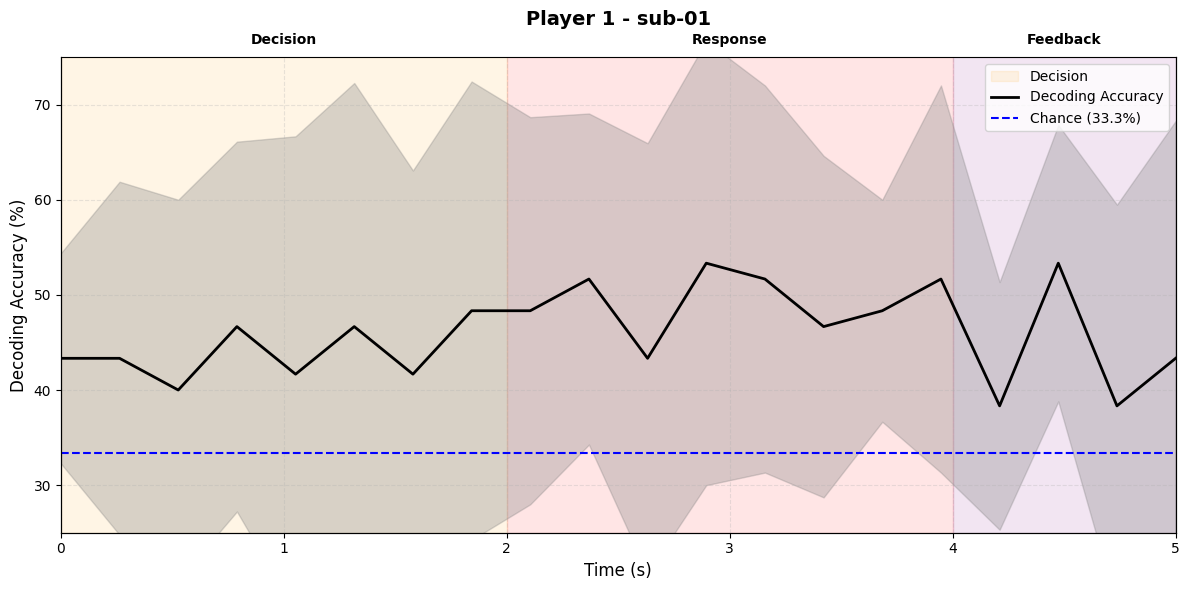

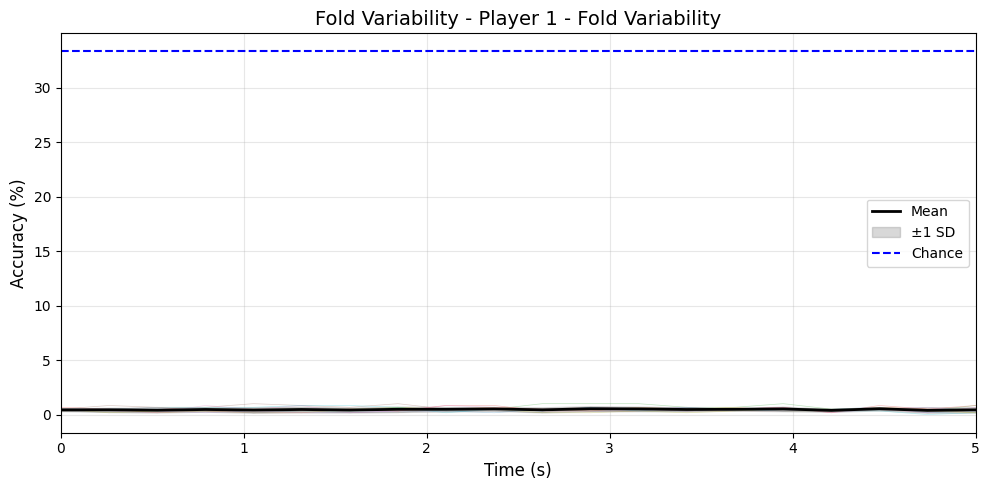

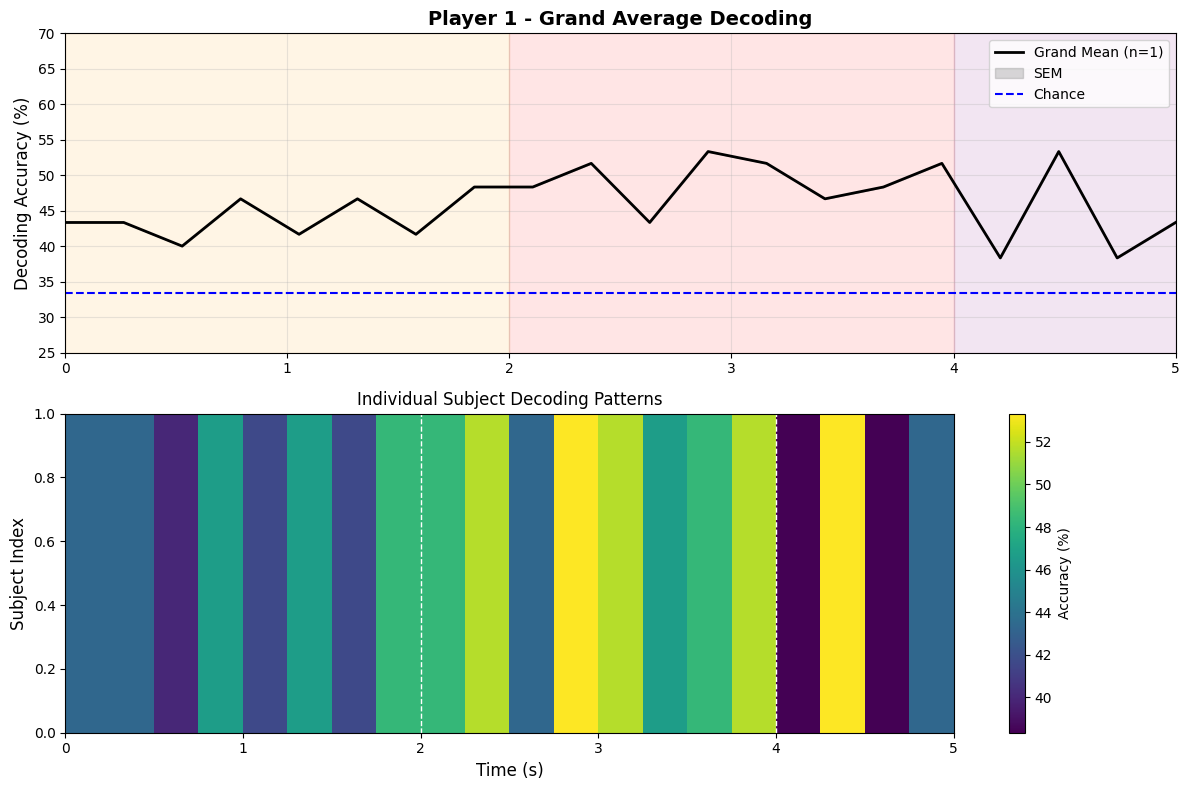

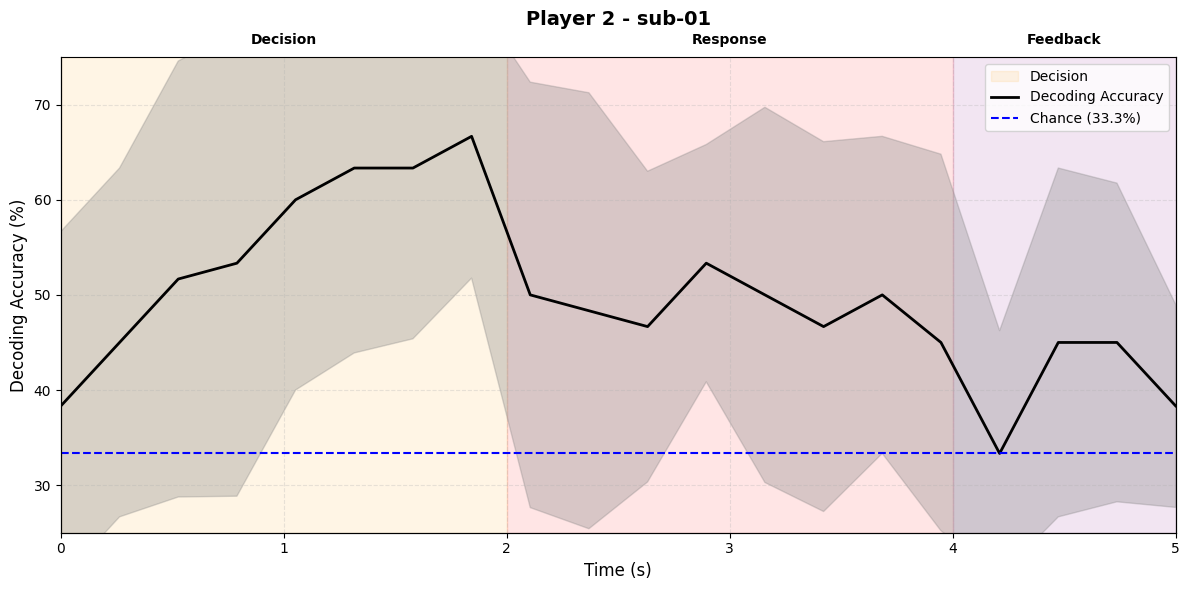

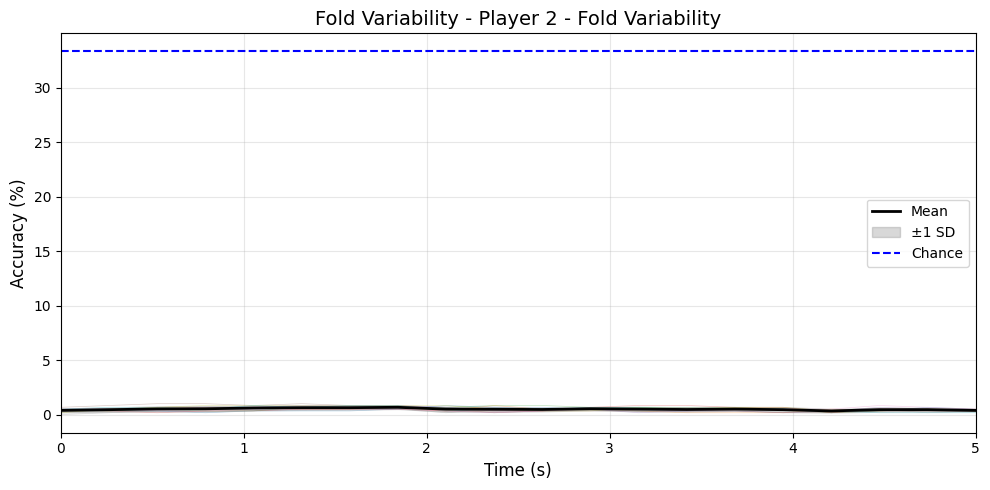

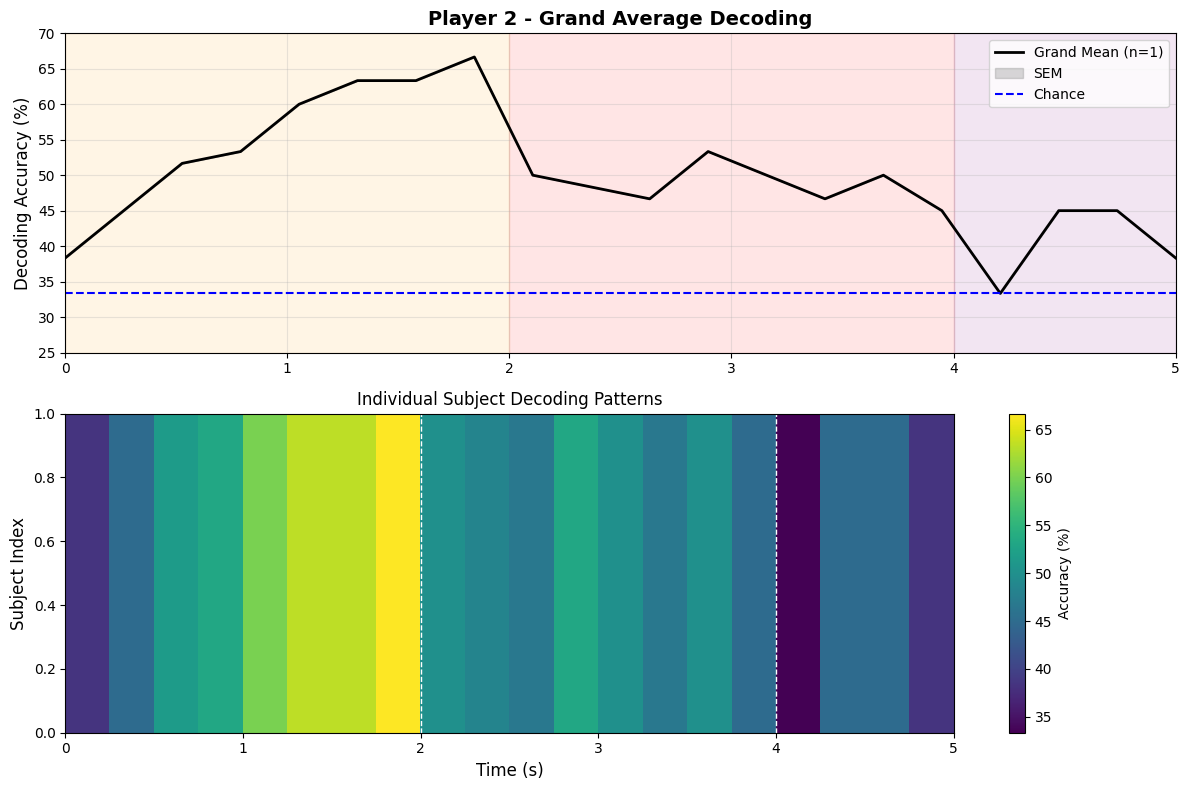

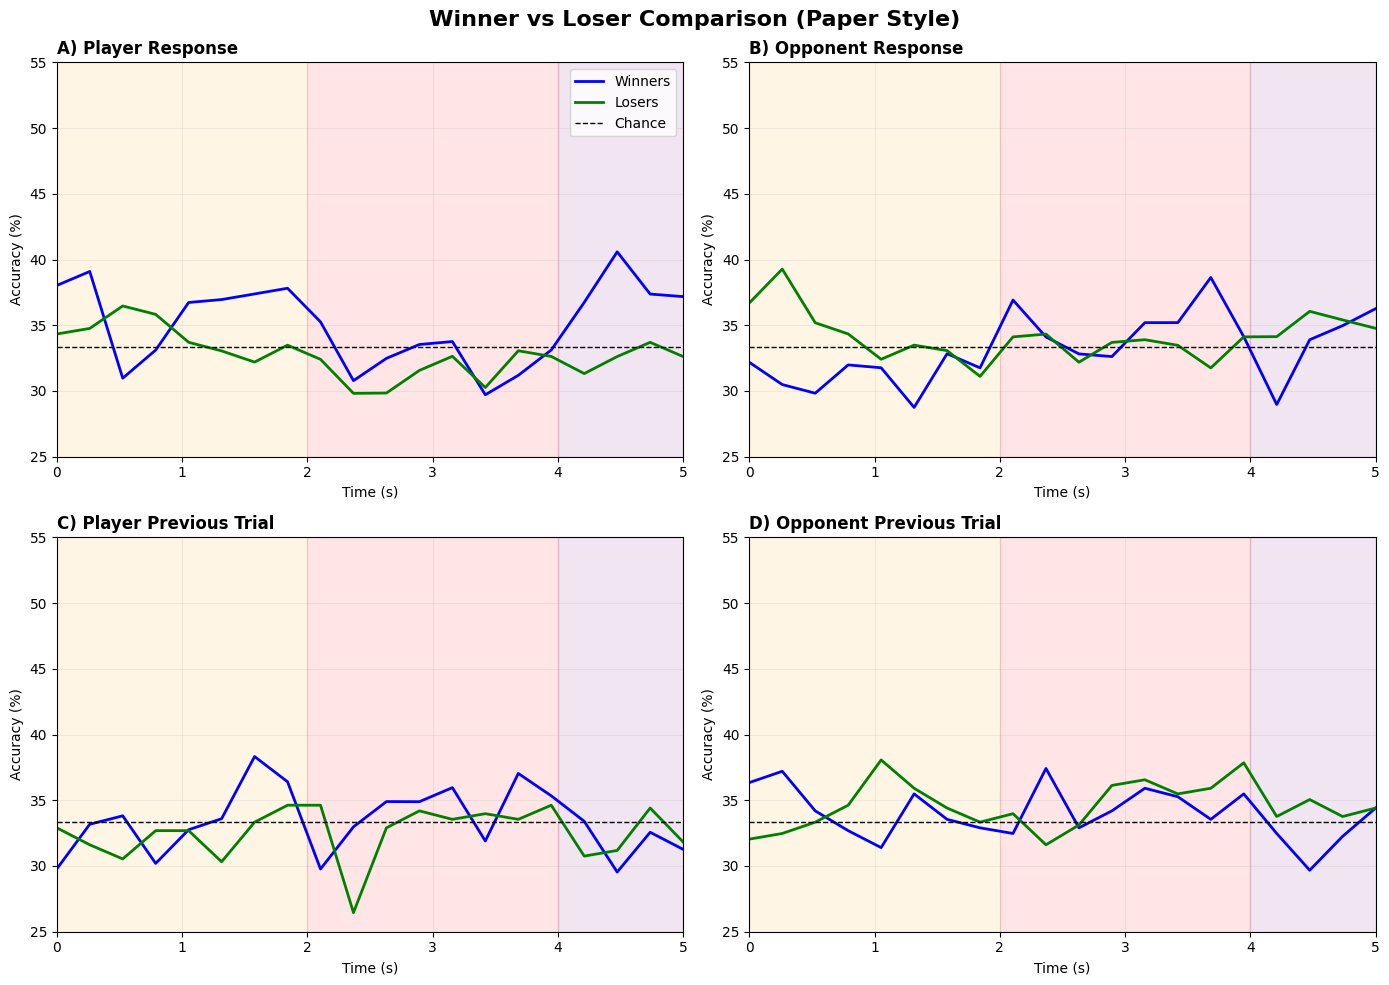


--- Winner Grand Averages ---
  Winner Statistics:
    N: 1
    Mean accuracy: 35.09%
    Peak accuracy: 40.59% at bin 17

--- Loser Grand Averages ---
  Loser Statistics:
    N: 1
    Mean accuracy: 32.82%
    Peak accuracy: 36.47% at bin 2

✅ Multi-Subject Analysis Complete with Enhanced Statistics!

   COMPREHENSIVE STATISTICS SUMMARY

Player 1 (N=1):
  Overall accuracy: 46.00% ± 4.70%
  Against chance (33.33%): t=11.760, p=0.0000 (SIGNIFICANT)

Player 2 (N=1):
  Overall accuracy: 49.67% ± 8.46%
  Against chance (33.33%): t=8.418, p=0.0000 (SIGNIFICANT)

Winner vs Loser Comparison:
  Winners (N=1): 35.09% ± 0.00%
  Losers (N=1): 32.82% ± 0.00%
  Group difference: t=nan, p=nan (NOT SIGNIFICANT)


/Users/abijithlakshmanan/Library/Python/3.9/lib/python/site-packages/scipy/stats/_stats_py.py:1087: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
/Users/abijithlakshmanan/Library/Python/3.9/lib/python/site-packages/scipy/stats/_stats_py.py:1087: RuntimeWarning: invalid value encountered in scalar multiply
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero


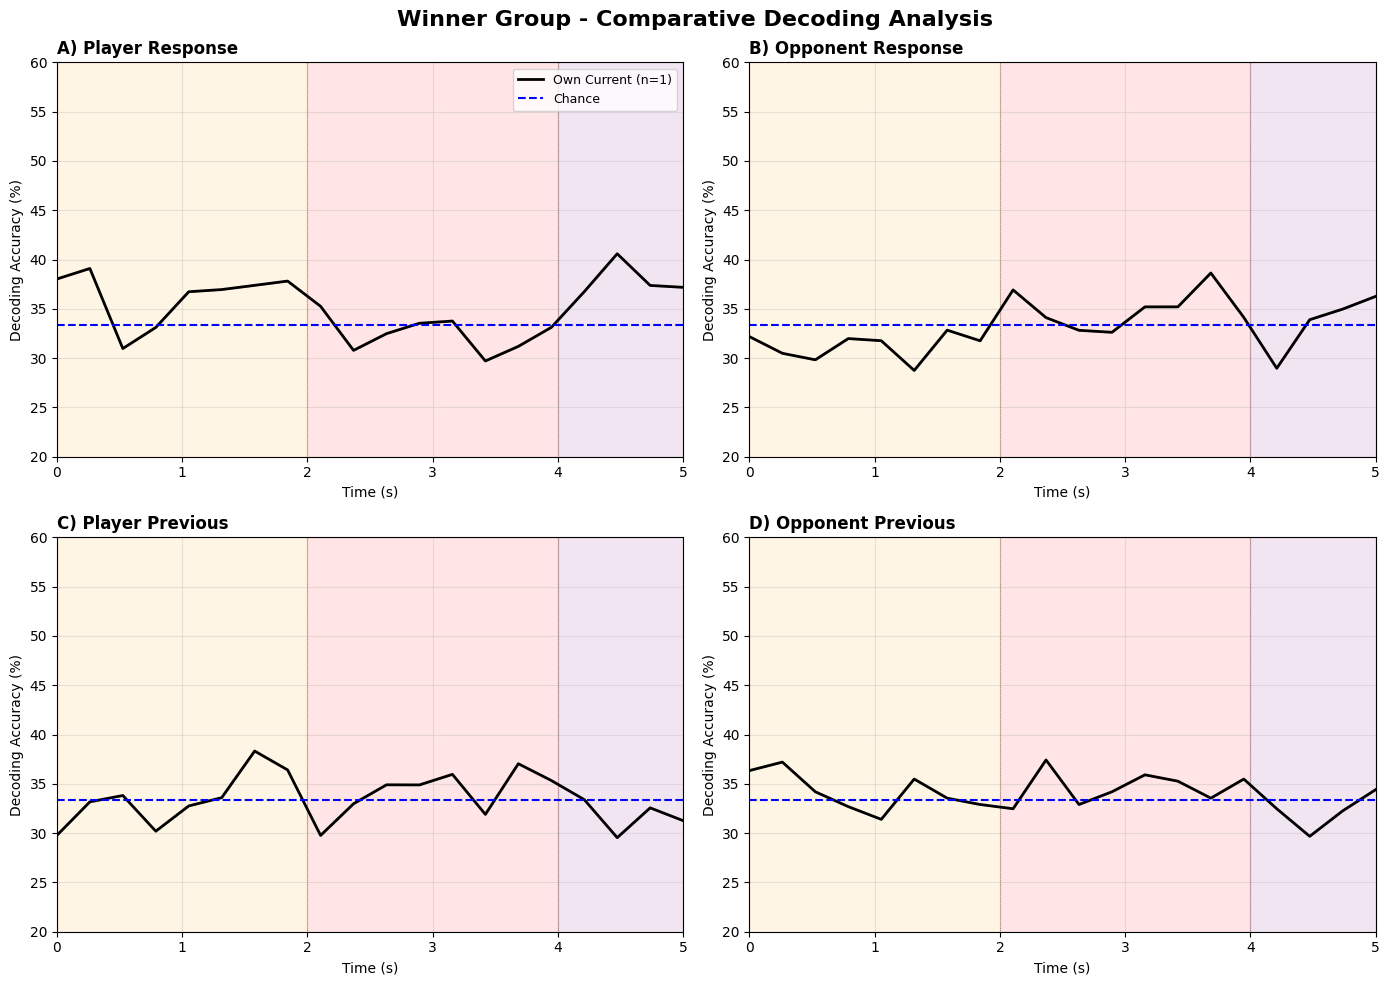

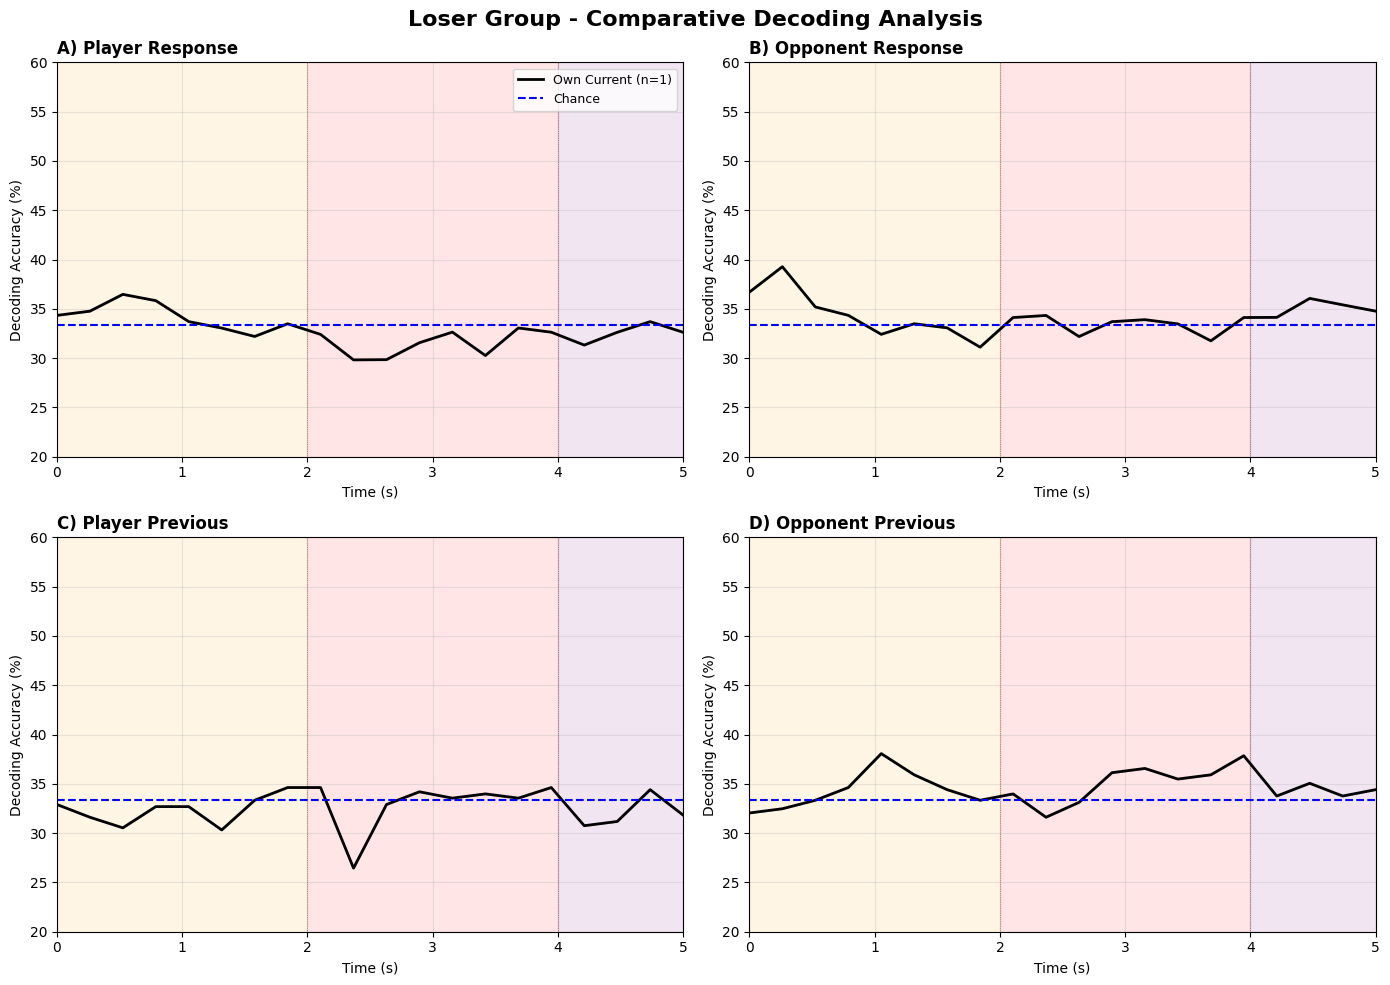

In [ ]:
# =================================================================
# 1. CONFIGURATION (MULTI-SUBJECT DYNAMIC)
# =================================================================
import step1_loading
import step2_preprocessing
import step3_epoching
import step4_pseudotrials
import step5_decoding
import step6_visualization
import step7_comparison
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dynamically generate Subject IDs from 01 to 34
START_SUB = 1
END_SUB = 1
SUBJECT_IDS = [f"sub-{i:02d}" for i in range(START_SUB, END_SUB + 1)]

BASIC_PATH = 'project/ds006761'

print(f"--- CONFIGURATION ---")
print(f"Target Subjects: {len(SUBJECT_IDS)} subjects")
print(f"Range: {SUBJECT_IDS[0]} to {SUBJECT_IDS[-1]}")

# Storage for Grand Average Analysis
# 1. Main Decoding
group_results = {1: [], 2: []} 

# 2. Comparative Decoding (Grouping by Game Outcome)
keys = ['Own Current', 'Opponent Current', 'Own Previous', 'Opponent Previous']
group_comp_results = {
    'Winner': {k: [] for k in keys},
    'Loser':  {k: [] for k in keys}
}

print(f"\n--- STARTING PIPELINE ---")

# =================================================================
# 2. OUTER LOOP: SUBJECTS
# =================================================================
for subject_id in SUBJECT_IDS:
    print(f"\n" + "#"*60)
    print(f"   PROCESSING SUBJECT: {subject_id}")
    print("#"*60)
    
    # Load Data for this Subject
    try:
        raw_p1_full, raw_p2_full = step1_loading.load_and_split_data(subject_id, BASIC_PATH)
    except Exception as e:
        print(f"❌ Failed to load {subject_id}: {e}")
        continue


    # --- DETERMINE GAME WINNER (Logic added) ---
    # We read the events file to count wins
    try:
        ev_file = f'{BASIC_PATH}/{subject_id}/eeg/{subject_id}_task-RPS_events.tsv'
        ev_df = pd.read_csv(ev_file, sep='\t')
        
        # Calculate scores (1=Rock, 2=Paper, 3=Scissors)
        # Logic: (P1 - P2) % 3 == 1 means P1 wins.
        p1_vals = ev_df['player1_resp'].values
        p2_vals = ev_df['player2_resp'].values
        
        # Count wins excluding NaNs
        valid_mask = np.isfinite(p1_vals) & np.isfinite(p2_vals)
        diff = (p1_vals[valid_mask] - p2_vals[valid_mask]) % 3
        
        p1_wins = np.sum(diff == 1)
        p2_wins = np.sum(diff == 2)
        
        subject_winner = 1 if p1_wins >= p2_wins else 2
        print(f"   -> Game Outcome: P1({p1_wins}) vs P2({p2_wins}) => Winner is Player {subject_winner}")
        
    except Exception as e:
        print(f"   ⚠️ Could not determine winner, defaulting to P1: {e}")
        subject_winner = 1
    # -------------------------------------------

# =================================================================
# 3. INNER LOOP: PLAYERS (1 & 2)
# =================================================================
for player_num, raw_data in zip([1, 2], [raw_p1_full, raw_p2_full]):
    
    if raw_data is None:
        print(f"   -> Skipping Player {player_num} (No Data)")
        continue
        
    print(f"\n   --- Player {player_num} Analysis ---")

    # A. PREPROCESSING + ICA
    raw_clean = step2_preprocessing.run_preprocessing(raw_data, subject_id, BASIC_PATH, player_num)

    # B. EPOCHING
    epochs_tuple, full_df = step3_epoching.run_epoching(raw_clean, subject_id, BASIC_PATH, player_num)

    # C. TIME BINNING
    epochs_binned = step4_pseudotrials.bin_and_stitch_time_course(epochs_tuple)

    labels = full_df[f'player{player_num}_resp'].values
    X_pseudo, y_pseudo = step4_pseudotrials.create_pseudo_trials_by_averaging(
        epochs_binned, labels, 
        random_seed=1  # Paper uses 1, not 42
    )

    # D. MAIN DECODING (Own Current)
    times, mean_scores, std_scores, fold_accuracies = step5_decoding.run_svm_decoding_with_pseudotrials(
        X_pseudo, y_pseudo
    )
    
    if mean_scores is not None:
        # Store all statistics
        group_results[player_num].append({
            'mean_scores': mean_scores,
            'std_scores': std_scores,
            'fold_accuracies': fold_accuracies,
            'subject_id': subject_id,
            'player_num': player_num
        })
        print(f"   -> ✅ Main Scores stored (mean: {np.mean(mean_scores):.2f}%)")
    else:
        print("   -> ❌ Main Decoding failed.")

    # Step G: Comparative Analysis
    comp_results = step7_comparison.run_comparative_analysis(epochs_binned, full_df, player_num)

    # Store these scores based on Winner/Loser status
    if player_num == subject_winner:
        group_key = 'Winner'
    else:
        group_key = 'Loser'

    for task_name, task_scores in comp_results.items():
        if task_scores is not None:
            # Append to 'Winner' or 'Loser' dict
            group_comp_results[group_key][task_name].append(task_scores)
    
    print(f"   -> ✅ Comparative Scores stored in '{group_key}' group.")

# =================================================================
# 4. FINAL STEP: GRAND AVERAGE VISUALIZATION WITH STATISTICS
# =================================================================
print("\n" + "="*60)
print("   GENERATING GRAND AVERAGE PLOTS WITH STATISTICS")
print("="*60)

# Plot individual player results with statistics
for player_num in [1, 2]:
    if group_results[player_num]:
        print(f"\n--- Player {player_num} Statistics ---")
        
        # Get the first subject for example plots
        first_result = group_results[player_num][0]
        
        # Plot with confidence intervals for one subject
        time_axis = np.linspace(0, 5.0, len(first_result['mean_scores']))
        
        # Plot with paper-style visualization
        fig, ax = step6_visualization.plot_decoding_with_confidence(
            time_axis, 
            first_result['mean_scores'], 
            first_result['std_scores'],
            title=f"Player {player_num} - {first_result['subject_id']}",
            chance_level=33.33  # RPS has 3 classes
        )
        
        
        # Plot grand average across all subjects
        step6_visualization.plot_grand_average_with_stats(group_results, player_num)

# Change the comparative plotting to use paper-like visualization:
print(f"\n--- Comparative Analysis (Paper Style) ---")

# Create a combined figure for winners vs losers similar to paper Figure 3
if group_comp_results['Winner']['Own Current'] and group_comp_results['Loser']['Own Current']:
    # Create a figure with 4 subplots for the 4 conditions
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Winner vs Loser Comparison (Paper Style)', 
                 fontsize=16, fontweight='bold')
    
    conditions = ['Own Current', 'Opponent Current', 'Own Previous', 'Opponent Previous']
    titles = ['A) Player Response', 'B) Opponent Response', 
              'C) Player Previous Trial', 'D) Opponent Previous Trial']
    
    time_axis = np.linspace(0, 5.0, 20)
    
    for idx, (ax, condition, title) in enumerate(zip(axes.flatten(), conditions, titles)):
        # Add phase shading (paper style)
        phases = [('Decision', 0, 2, 'orange', 0.1),
                  ('Response', 2, 4, 'red', 0.1),
                  ('Feedback', 4, 5, 'purple', 0.1)]
        
        for phase_name, start, end, color, alpha in phases:
            ax.axvspan(start, end, alpha=alpha, color=color)
        
        # Plot winners
        if group_comp_results['Winner'][condition]:
            winner_means = np.mean(group_comp_results['Winner'][condition], axis=0)
            ax.plot(time_axis, winner_means, 'b-', linewidth=2, label='Winners')
        
        # Plot losers
        if group_comp_results['Loser'][condition]:
            loser_means = np.mean(group_comp_results['Loser'][condition], axis=0)
            ax.plot(time_axis, loser_means, 'g-', linewidth=2, label='Losers')
        
        ax.axhline(y=33.33, color='black', linestyle='--', linewidth=1, label='Chance')
        ax.set_xlabel('Time (s)', fontsize=10)
        ax.set_ylabel('Accuracy (%)', fontsize=10)
        ax.set_title(title, fontsize=12, fontweight='bold', loc='left')
        ax.set_xlim([0, 5])
        ax.set_ylim([25, 55])
        ax.grid(True, alpha=0.2)
        
        if idx == 0:
            ax.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

# Plot comparative results (Winners vs Losers)
grand_time_axis = np.linspace(0, 5.0, 20)

for group_name in ['Winner', 'Loser']:
    print(f"\n--- {group_name} Grand Averages ---")
    
    # Check if we have data
    if len(group_comp_results[group_name]['Own Current']) > 0:
        # Plot Comparative Decoding (4 Lines)
        step7_comparison.plot_grand_average_comparison(
            group_comp_results[group_name], 
            group_name
        )
        
        # Calculate and print statistics for winners/losers
        all_scores = group_comp_results[group_name]['Own Current']
        mean_scores = np.mean(all_scores, axis=0)
        std_scores = np.std(all_scores, axis=0)
        
        print(f"  {group_name} Statistics:")
        print(f"    N: {len(all_scores)}")
        print(f"    Mean accuracy: {np.mean(mean_scores):.2f}%")
        print(f"    Peak accuracy: {np.max(mean_scores):.2f}% at bin {np.argmax(mean_scores)}")
    else:
        print(f"  No data for {group_name} group")

print("\n✅ Multi-Subject Analysis Complete with Enhanced Statistics!")

# =================================================================
# 5. COMPREHENSIVE STATISTICS SUMMARY
# =================================================================
print("\n" + "="*60)
print("   COMPREHENSIVE STATISTICS SUMMARY")
print("="*60)

# Calculate overall statistics
for player_num in [1, 2]:
    if group_results[player_num]:
        # Extract all mean scores
        all_means = [result['mean_scores'] for result in group_results[player_num]]
        mean_matrix = np.array(all_means)
        
        # Overall statistics
        grand_mean = np.mean(mean_matrix, axis=0)
        overall_mean = np.mean(grand_mean)
        overall_std = np.std(mean_matrix.flatten())
        
        print(f"\nPlayer {player_num} (N={len(group_results[player_num])}):")
        print(f"  Overall accuracy: {overall_mean:.2f}% ± {overall_std:.2f}%")
        
        # Check against chance (33.33%)
        from scipy import stats
        t_stat, p_value = stats.ttest_1samp(mean_matrix.flatten(), 33.33)
        significance = "SIGNIFICANT" if p_value < 0.05 else "NOT SIGNIFICANT"
        print(f"  Against chance (33.33%): t={t_stat:.3f}, p={p_value:.4f} ({significance})")

# Winner vs Loser comparison
if len(group_comp_results['Winner']['Own Current']) > 0 and len(group_comp_results['Loser']['Own Current']) > 0:
    print(f"\nWinner vs Loser Comparison:")
    
    winner_scores = np.mean(group_comp_results['Winner']['Own Current'], axis=1)
    loser_scores = np.mean(group_comp_results['Loser']['Own Current'], axis=1)
    
    print(f"  Winners (N={len(winner_scores)}): {np.mean(winner_scores):.2f}% ± {np.std(winner_scores):.2f}%")
    print(f"  Losers (N={len(loser_scores)}): {np.mean(loser_scores):.2f}% ± {np.std(loser_scores):.2f}%")
    
    # T-test between groups
    from scipy import stats
    t_stat, p_value = stats.ttest_ind(winner_scores, loser_scores, equal_var=False)
    significance = "SIGNIFICANT" if p_value < 0.05 else "NOT SIGNIFICANT"
    print(f"  Group difference: t={t_stat:.3f}, p={p_value:.4f} ({significance})")